In [1]:
import xarray as xr
import numpy as np
import pandas as pd
from PAD_on_sphere import calculate_attributions_from_xarrays
from PAD_postprocess import compute_regional_stats
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## Read sample data

Both sample fields are on a 0.25 latlon degree grid. \
Below we plot the observed field, and the standard gridpoint-by-gridpoint error.

In [2]:
fcst = xr.open_dataarray("sample_data/example_field_A.nc")
obs = xr.open_dataarray("sample_data/example_field_B.nc")

Text(0.5, 1.0, 'Observed precipitation (mm)')

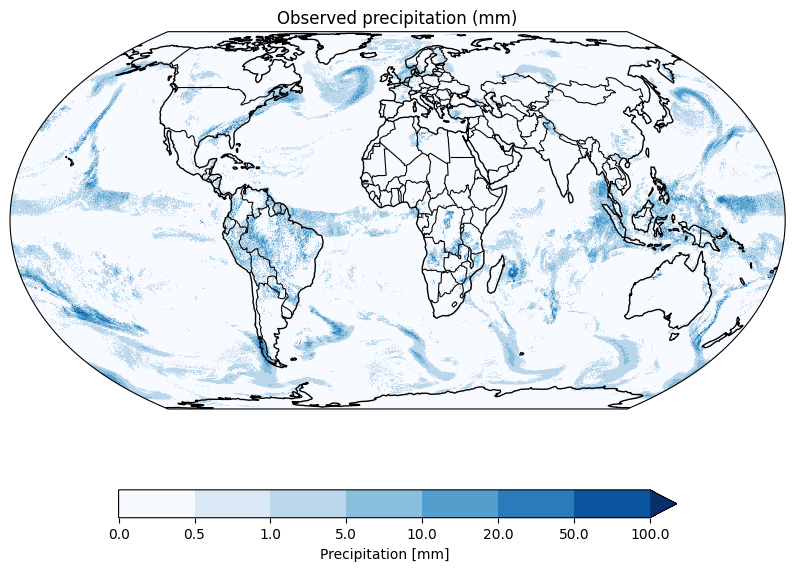

In [3]:
fig = plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.EqualEarth())
obs.plot(
    ax=ax, x="lon", y="lat", transform=ccrs.PlateCarree(),
    cmap="Blues", 
    levels=[0,0.5,1,5,10,20,50,100],
    cbar_kwargs = {"orientation": "horizontal",
                   "label": "Precipitation [mm]",
                   "shrink": 0.6
                  },
)
ax.coastlines(color="black")
ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=0.8, edgecolor="black")
plt.title('Observed precipitation (mm)')

Text(0.5, 1.0, 'Precipitation error (mm)')

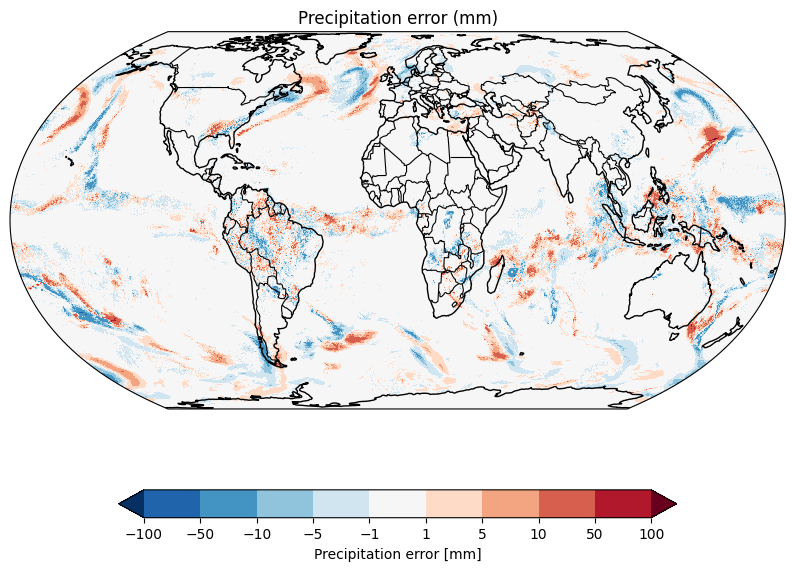

In [4]:
fig = plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.EqualEarth())
(fcst-obs).plot(
    ax=ax, x="lon", y="lat", transform=ccrs.PlateCarree(),
    levels=[-100,-50,-10,-5,-1,1,5,10,50,100],
    cbar_kwargs = {"orientation": "horizontal",
                   "label": "Precipitation error [mm]",
                   "shrink": 0.6
                  },
)
ax.coastlines(color="black")
ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=0.8, edgecolor="black")
plt.title('Precipitation error (mm)')

### Reshape the data to have a single "gridpoint" dimension instead of "lat" and "lon"

In [5]:
fcst = fcst.stack(stack=("lat", "lon"))
obs = obs.stack(stack=("lat", "lon"))
fcst = fcst.assign_coords(gridpoint=('stack', range(fcst.sizes['stack']))).swap_dims({"stack": "gridpoint"}).drop_vars("stack")
obs = obs.assign_coords(gridpoint=('stack', range(obs.sizes['stack']))).swap_dims({"stack": "gridpoint"}).drop_vars("stack")

In [6]:
fcst

<xarray.DataArray 'precipitation' (gridpoint: 1038240)> Size: 4MB
array([0., 0., 0., ..., 0., 0., 0.], shape=(1038240,), dtype=float32)
Coordinates:
  * gridpoint  (gridpoint) int64 8MB 0 1 2 3 ... 1038236 1038237 1038238 1038239
    lat        (gridpoint) float32 4MB -90.0 -90.0 -90.0 ... 90.0 90.0 90.0
    lon        (gridpoint) float32 4MB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8

### Compute grid-area (used internally to convert precipitation from heigh in mm to volume in m^3)

In [7]:
dlat = 0.25 # in deg
dlon = 0.25 # in deg
Earth_radius = 6371 # in km
area = (
    np.deg2rad(dlat) * Earth_radius
    * np.deg2rad(dlon) * Earth_radius * np.cos(np.deg2rad(fcst.lat))
) # in km^2

## Compute PAD-on-sphere attributions, and compute total/average values at each gridpoint

The attribution plan is always returned as a pandas dataframe. \
By setting gridded_output to True, we also get a gridpoint summary dataset with total attributed volume, average distance attributed and the non-attributed precipitation at each grid point. This is only possible for the case with equal grids. Cutoffs are great-circle distances in kilometres. 
A positive distance value indicates water exported from that gridpoint elsewhere (i.e. fcst>obs). \
A negative distance value indicates water imported from elsewhere (i.e. fcst<obs). \
The volume includes both imported and exported water. But at each grid point there is only either an import or an export. \
A positive error indicates unattributed precip in the forecasts (i.e. fcst>obs or "false alarm"). \
A negative error indicates unattributed precip in the observations (i.e. fcst<obs or "miss").

Saved outputs below predate this update; rerun the notebook with the rebuilt ABI-3 library.

In [8]:
attributions_df, gridded_ds = calculate_attributions_from_xarrays(
    fcst, obs, area, same_grid=True, cutoff=3000, gridded_output=True, random_seed=5489
)

----- preprocessing: 0.0260151 s
PAD random seed: 5489
----- kdtree construction: 0.244967 s
----- attribution: 2.16638 s


In [9]:
attributions_df

,distance_m,volume_m3,gridpoint_fcst,gridpoint_obs
0,0,2.572534e+01,1913,1913
1,0,2.572534e+01,1914,1914
2,0,2.572534e+01,1915,1915
3,0,2.572534e+01,1916,1916
4,0,2.572534e+01,1917,1917
...,...,...,...,...
1330686,2858857,7.177337e+05,298695,176386
1330687,2872491,6.294906e+05,298695,171889
1330688,2890416,3.713282e+04,298695,166137
1330689,2985234,6.560114e+05,307332,354974


In [10]:
gridded_ds

<xarray.Dataset> Size: 42MB
Dimensions:   (gridpoint: 1038240)
Coordinates:
    lat       (gridpoint) float64 8MB -90.0 -90.0 -90.0 -90.0 ... 90.0 90.0 90.0
    lon       (gridpoint) float64 8MB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Dimensions without coordinates: gridpoint
Data variables:
    volume    (gridpoint) float64 8MB nan nan nan nan nan ... nan nan nan nan
    distance  (gridpoint) float64 8MB nan nan nan nan nan ... nan nan nan nan
    error     (gridpoint) float64 8MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

## Compute global and regional averages

In [11]:
import regionmask as rm

In [12]:
region_dict = {
    'north_hem': np.array([[-180., 90.], [-180., 20.], [ 180., 20.], [ 180., 90.]]),
    'south_hem': np.array([[-180., -20.], [-180., -90.], [ 180., -90.], [ 180., -20.]]),
    'tropics': np.array([[-180., 20.], [-180., -20.], [ 180., -20.], [ 180., 20.]]),
    'europe': np.array([[-12.5, 75. ], [-12.5, 35. ], [ 42.5, 35. ], [ 42.5, 75. ]]),
    'global': np.array([[-180., 90.], [-180., -90.], [ 180., -90.], [ 180., 90.]])
}

In [13]:
regions = rm.Regions(region_dict.values(), names=region_dict.keys(), name="Regions", overlap=True)

In [14]:
region_masks = regions.mask_3D(fcst)
region_masks = region_masks.assign_coords({"region": region_masks.names}).drop_vars(["names", "abbrevs"])

In [15]:
region_masks

<xarray.DataArray 'mask' (region: 5, gridpoint: 1038240)> Size: 5MB
array([[False, False, False, ...,  True,  True,  True],
       [ True,  True,  True, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [ True,  True,  True, ...,  True,  True,  True]],
      shape=(5, 1038240))
Coordinates:
  * region     (region) <U9 180B 'north_hem' 'south_hem' ... 'europe' 'global'
  * gridpoint  (gridpoint) int64 8MB 0 1 2 3 ... 1038236 1038237 1038238 1038239
    lat        (gridpoint) float32 4MB -90.0 -90.0 -90.0 ... 90.0 90.0 90.0
    lon        (gridpoint) float32 4MB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Attributes:
    standard_name:  region

In [16]:
regional_statistics = compute_regional_stats(gridded_ds, region_masks, area)

In [17]:
regional_statistics.to_dataframe()

,mean_distance,residual_mae
region,,
north_hem,769.390371,0.030677
south_hem,559.009097,0.081272
tropics,494.953563,0.080755
europe,978.346836,0.054385
global,577.147009,0.064502


## Prepare the data for plotting

Before plotting, we need to reshape the data to depend on lat/lon coordinates again, instead of the single gridpoint coordinate.

In [18]:
def reshape_data(ds, fill_na_lons=359.9999):
    """ This function unstacks the data to depend on lat/lon again."""
    # Group points in the same ascending order used for the output latitude axis.
    ds = ds.sortby(["lat", "lon"])
    # get unique list of lats, in ascending order
    lats = ds.lat.groupby(ds.lat).mean().sortby("lat", ascending=True)
    nlats = ds.lat.groupby(ds.lat).count().sizes["lat"]

    # get number of longitudes per each lat
    nlons = ds.lat.groupby(ds.lat).count().sortby("lat", ascending=True).rename({"lat": "j"}).assign_coords({"j": range(nlats)}).rename("nlon")

    # expand lats to depend also on i coordinate
    lats = lats.rename({"lat": "j"}).assign_coords({"j": range(nlats)}) #.expand_dims(dim={"i": range(nlons.max().values)})

    # get the indices to slice the data in consecutive longitude chunks
    idx = np.insert(nlons.cumsum().values, 0, 0)

    # slice the data and reshape it to an (i,j)-dependant array
    tmpls = list()
    for j in lats.j.values:
        ads = ds.isel(gridpoint=slice(idx[j], idx[j+1])).rename({"gridpoint": "i"}).assign_coords({"i": range(nlons.isel(j=j).values)})
        tmpls.append(ads)
    ds2 = xr.concat(tmpls, dim="j").assign_coords({"j": lats.j})

    # fill nan longitudes (this value should be changed for regional plots)
    ds2['lon'] = ds2.lon.fillna(fill_na_lons)
    # fill nan latitudes 
    ds2['lat'] = lats
    
    ds2 = ds2.set_coords(("lat", "lon"))
    return ds2

In [19]:
gridded_ds = reshape_data(gridded_ds)

In [20]:
gridded_ds_smooth = gridded_ds.coarsen(i=20, boundary="pad").mean().coarsen(j=20, boundary="pad").mean()

## Plot grid point values

Text(0.5, 1.0, 'transported distance')

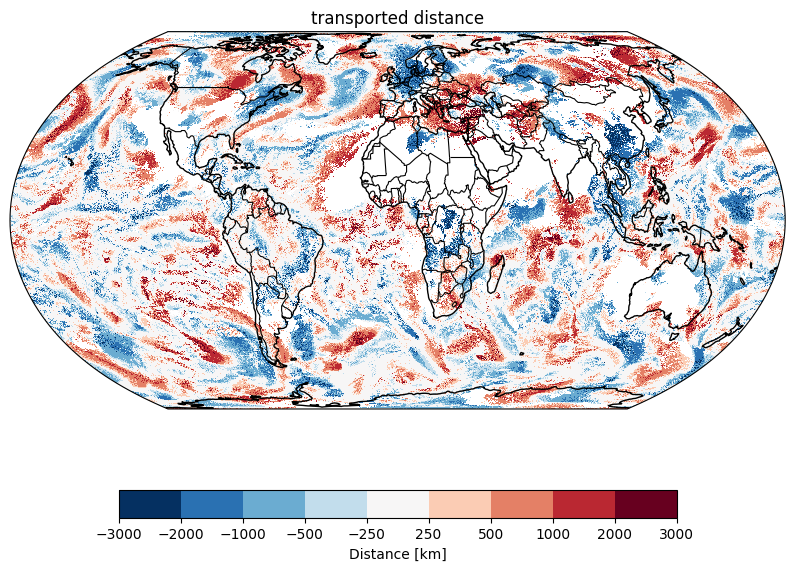

In [21]:
fig = plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.EqualEarth())
(gridded_ds.distance/1000).plot(
    ax=ax, x="lon", y="lat", transform=ccrs.PlateCarree(),
    levels=[-3000,-2000,-1000,-500,-250,250,500,1000,2000,3000],
    cbar_kwargs = {"orientation": "horizontal",
                   "label": "Distance [km]",
                   "shrink": 0.6,
                  },
)
ax.coastlines(color="black")
ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=0.8, edgecolor="black")
plt.title('transported distance')

Text(0.5, 1.0, 'Volume (shaded) and distance (contours) transported')

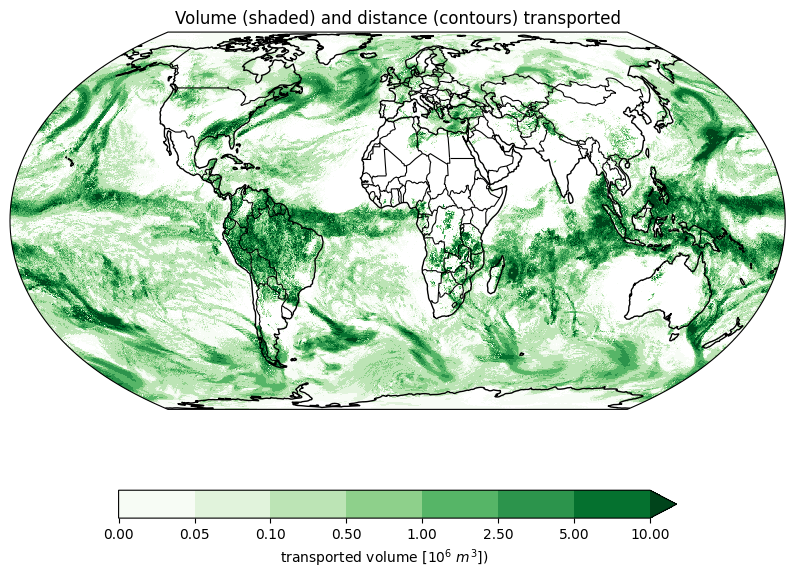

In [22]:
fig = plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.EqualEarth())
(gridded_ds.volume / 1000000).plot(
    ax=ax, x="lon", y="lat", transform=ccrs.PlateCarree(),
    cmap="Greens", levels=[0, 0.05, 0.1, 0.5, 1, 2.5, 5, 10],
    cbar_kwargs = {"orientation": "horizontal",
                   "label": r'transported volume [$10^6$ $m^3$])',
                   "shrink": 0.6,
                  },
)
ax.coastlines(color="black")
ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=0.8, edgecolor="black")
plt.title("Volume (shaded) and distance (contours) transported")

Text(0.5, 1.0, 'Distance (shaded) and volume (contours) transported')

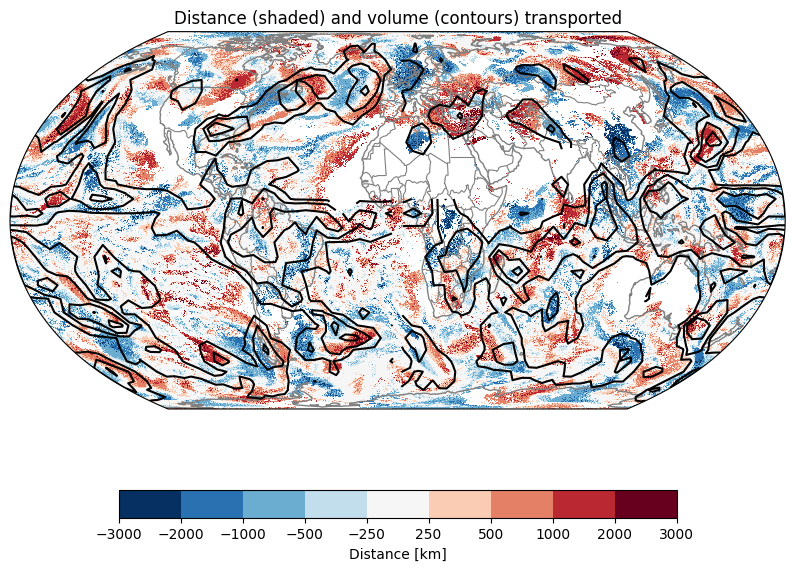

In [23]:
fig = plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.EqualEarth())
(gridded_ds.distance / 1000).plot(
    ax=ax, x="lon", y="lat", transform=ccrs.PlateCarree(),
    levels=[-3000,-2000,-1000,-500,-250,250,500,1000,2000,3000],
    cbar_kwargs = {"orientation": "horizontal",
                   "label": "Distance [km]",
                   "shrink": 0.6,
                  },
)
# This contours do not work well in the Greenwhich meridian
ax.contour(gridded_ds_smooth.lon.broadcast_like(gridded_ds_smooth.volume).transpose("j", "i"), 
           gridded_ds_smooth.lat.broadcast_like(gridded_ds_smooth.volume).transpose("j", "i"), 
           gridded_ds_smooth.volume.transpose("j", "i") / 1000000, 
           transform=ccrs.PlateCarree(),
           levels=[0.5, 2, 5, 10], 
           colors="black")
ax.coastlines(color="grey")
ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=0.8, edgecolor="grey")
plt.title("Distance (shaded) and volume (contours) transported")

Text(0.5, 1.0, 'Transported distance*volume')

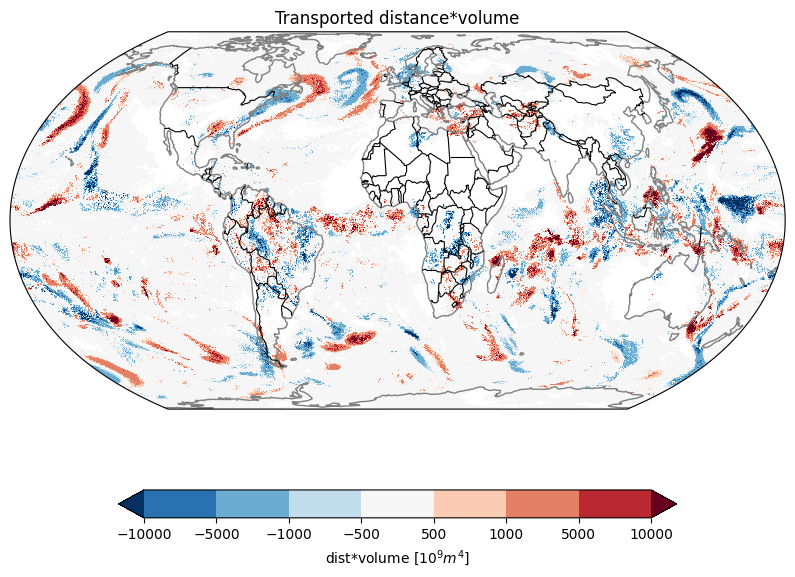

In [24]:
fig = plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.EqualEarth())
(gridded_ds.volume / 1000000 * gridded_ds.distance / 1000).plot(
    ax=ax, x="lon", y="lat", transform=ccrs.PlateCarree(),
    levels=[-10000,-5000,-1000,-500,500,1000,5000,10000],
    cbar_kwargs = {"orientation": "horizontal",
                   "label": r'dist*volume [$10^9 m^4$]',
                   "shrink": 0.6,
                  },
)
ax.coastlines(color="grey")
ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=0.8, edgecolor="black")
plt.title("Transported distance*volume")

Text(0.5, 1.0, 'unattributed precipitation in fcst (red) and obs (blue)')

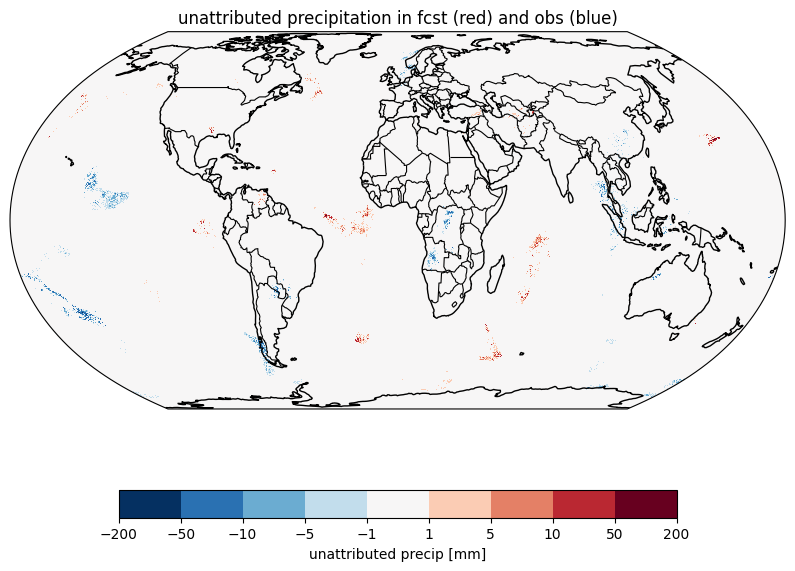

In [25]:
fig = plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.EqualEarth())
gridded_ds.error.plot(
    ax=ax, x="lon", y="lat", transform=ccrs.PlateCarree(),
    cmap="RdBu_r", 
    levels=[-200,-50,-10,-5,-1,1,5,10,50,200],
    cbar_kwargs = {"orientation": "horizontal",
                   "label": "unattributed precip [mm]",
                   "shrink": 0.6,
                  },
)
ax.coastlines(color="black")
ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=0.8, edgecolor="black")
plt.title('unattributed precipitation in fcst (red) and obs (blue)')